## Online Retail Dataset

### Exploratory Data Analysis (EDA)
#### Overview
This notebook examines transaction patterns, customer behavior, and revenue dynamics to uncover insights that guide RFM feature creation and segmentation, highlighting purchasing trends, engagement levels, and value concentration across customers and markets.

#### Objective
To analyze transaction patterns, customer behavior, and revenue distribution in the Online Retail dataset to uncover key insights that inform effective RFM-based customer segmentation.

#### Activities Covered
We will:
1. **Validate Dataset Integrity** – Conduct a dataset sanity check to confirm successful loading, structural consistency, and correct variable availability prior to analysis.
2. **Examine Transactional Distributions** – Perform univariate analysis on Quantity, UnitPrice,and TotalPrice to understand the distribution and spread of transactional variables and identify dominant purchasing patterns.
3. **Assess Transactions per Customer** – Analyze the number of transactions per customer to understand purchasing frequency patterns across the customer base.
4. **Evaluate Revenue per Customer** – Examine total revenue generated by each customer to assess variability in customer spending contributions.
5. **Analyze Average Order Value** – Compute the average order value to understand typical customer spending per transaction.
6. **Assess Customer Revenue Concentration** – Conduct a Pareto analysis to determine whether a small proportion of customers contributes a disproportionate share of total revenue.
7. **Evaluate Month-of-Year Revenue Patterns** – Analyze revenue aggregated by month to identify seasonal purchasing trends and temporal revenue fluctuations.
8. **Analyze Monthly Transaction Trends** – Examine transaction volumes over time to understand changes in purchasing activity across months.
9. **Assess Revenue Share by Country** – Calculate revenue contribution by country to identify key geographic markets driving total sales.
10. **Analyze Transactions by Country** – Evaluate the distribution of transactions across countries to understand geographic purchasing activity.
11. **Examine Customer Revenue by Country** – Compute average revenue per customer across countries to assess differences in customer spending behavior by market.

#### Key Findings
1. **Dataset Integrity** – The dataset loaded successfully with the expected structure and data types, confirming readiness for analysis and ensuring reliable aggregation for downstream RFM feature construction.
2. **Transactional Distribution Analysis** – The distributions of Quantity, UnitPrice, and TotalPrice are strongly right-skewed, with the majority of transactions occurring at low quantities and modest transaction values, while a small number of transactions represent substantially larger purchases. This pattern indicates the presence of occasional bulk or high-value purchases that could disproportionately influence monetary metrics in customer-level analysis.
3. **Log-Transformed Distribution Analysis** – Applying log transformation has minimal impact on the distributions of Quantity and UnitPrice, which remain right-skewed, but it substantially improves the distribution of TotalPrice by reducing the impact of extreme transaction values. This suggests that transaction value is the primary driver of skewness in the dataset. and confirms the need to manage high-value transactions when constructing monetary-based customer metrics.
4. **Transactions per Customer** – The distribution of transactions per customer shows that most customers make only a small number of purchases, while a small subset of customers records very high transaction counts. This indicates significant variation in customer engagement levels.
5. **Revenue per Customer** – Customer revenue contributions are highly uneven, with most customers generating modest spending while a small group contributes disproportionately large revenue totals. This pattern highlights the presence of high-value customers whose purchasing behavior is likely to dominate overall revenue.
6. **Average Order Value** – The distribution of Average Order Value reveals substantial variation in customer spending intensity, with most customers placing moderate-value orders while a smaller segment records significantly higher spending per transaction. This variation indicates that monetary value differs not only through purchase frequency but also through transaction size,.. reinforcing the importance of monetary-based segmentation.
7. **Customer Revenue Concentration (Pareto Analysis)** – The Pareto curve rises sharply at the beginning before gradually flattening, showing that a relatively small proportion of customers(eg 20%) contributes the majority of total revenue (71%). This strong concentration of revenue among a limited number of customers confirms a classic Pareto distribution and emphasizes the need to identify and retain high-value customers.
8. **Month-of-Year Revenue Patterns** – Revenue trends increase gradually throughout the year before rising sharply toward the end of the period, with notable peaks occurring in September, October, and especially November. This pattern suggests strong seasonality linked to holiday-driven demand., indicating that recency will play an important role in identifying currently active versus potentially dormant customers.
9. **Monthly Transaction Trends** – Transaction activity follows a similar trajectory, with purchase volumes increasing progressively during the year and reaching their highest levels in October and November before declining in December. The alignment between transaction growth and revenue growth indicates that seasonal increases are driven by higher purchasing activity rather than simply larger transaction sizes.
10. **Revenue Share by Country** – The United Kingdom dominates total revenue, with significantly smaller contributions from other countries, indicating strong geographic concentration.
11. **Transactions by Country** – Transaction activity mirrors the revenue pattern, with the United Kingdom accounting for the vast majority of transactions. This confirms that the UK market as the primary driver of overall sales and customer engagement.
12. **Customer Revenue by Country** – When revenue is examined at the customer level, several international markets show higher revenue per customer, particularly EIRE, the Netherlands, and Australia, compared to the United Kingdom. This indicates that although the UK generates the highest total revenue through transaction volume, certain international markets demonstrate stronger individual customer purchasing power, which may influence the distribution of high-value RFM segments. stronger individual purchasing power despite lower overall transaction volumes.

#### Business Insights
1. **Revenue is highly concentrated among a small group of customers** - A minority of customers drives the majority of revenue, indicating that retaining high-value customers is critical to overall business performance.
2. **Customer engagement is uneven, with many low-frequency buyers** - Most customers purchase infrequently, suggesting an opportunity to increase retention and repeat purchase behavior through targeted engagement strategies.
3. **Seasonality significantly influences purchasing behavior** - Revenue and transaction volumes peak toward the end of the year, highlighting the importance of timing marketing campaigns and customer targeting around high-demand periods.
4. **High-value behavior is driven by both frequency and order size** - Customers differ not only in how often they purchase but also in how much they spend per transaction, reinforcing the need for a multi-dimensional segmentation approach.
5. **Geographic performance differs between volume and value** - While the UK dominates in total transactions and revenue, some international markets generate higher revenue per customer, indicating opportunities for targeted expansion or premium customer strategies.

**EDA Implications for RFM Analysis**
Customer behavior is highly uneven, with strong skewness in transaction values, low purchase frequency for most customers, and revenue concentrated among a small segment. These patterns validate the need for RFM analysis to differentiate customers based on recency, engagement, and spending value. RFM will enable targeted identification of high-value, loyal, and at-risk customer segments for strategic decision-making.


In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
#1. load the data
df = pd.read_csv('../data/data_processed/cleaned_online_retail.csv',parse_dates = ['InvoiceDate'])

#inspect the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 27.0+ MB


In [5]:
# 2. Univariate Analysis
# i) Check the distribution of numeric variables
df[['Quantity','UnitPrice','TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,11.022402,2.833364,19.459887
std,18.158425,2.792072,37.495541
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.390000
75%,12.000000,3.750000,19.800000
max,120.000000,14.950000,1794.000000


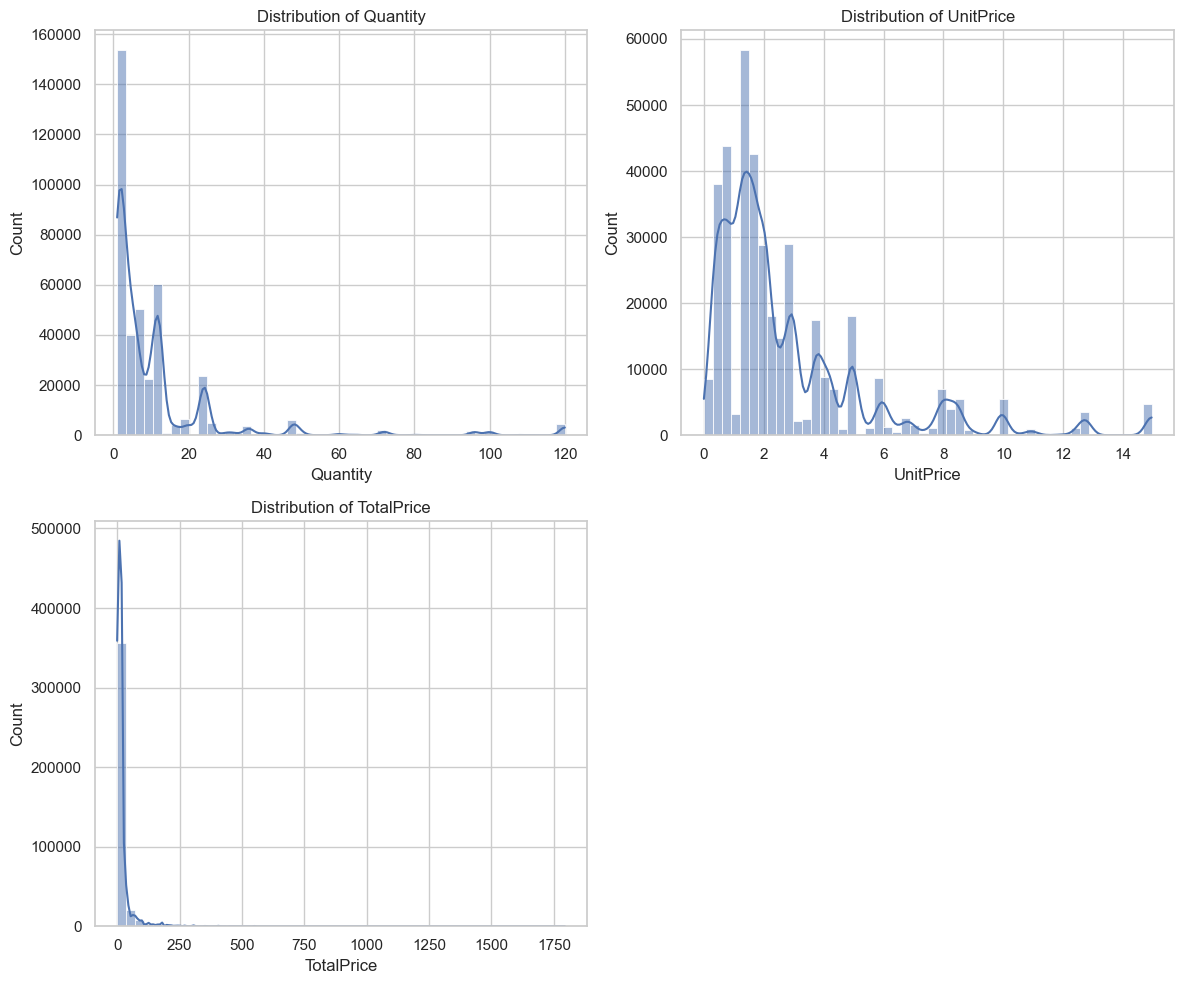

In [65]:
# ii) Visualize the distribution of numeric variables
numeric_cols = ['Quantity','UnitPrice','TotalPrice']
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,10))
for i, col in enumerate (numeric_cols,1):
    plt.subplot(2,2,i)
    sns.histplot(data=df, x=col, bins=50, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f'Numeric_cols_hist.png')
plt.show()


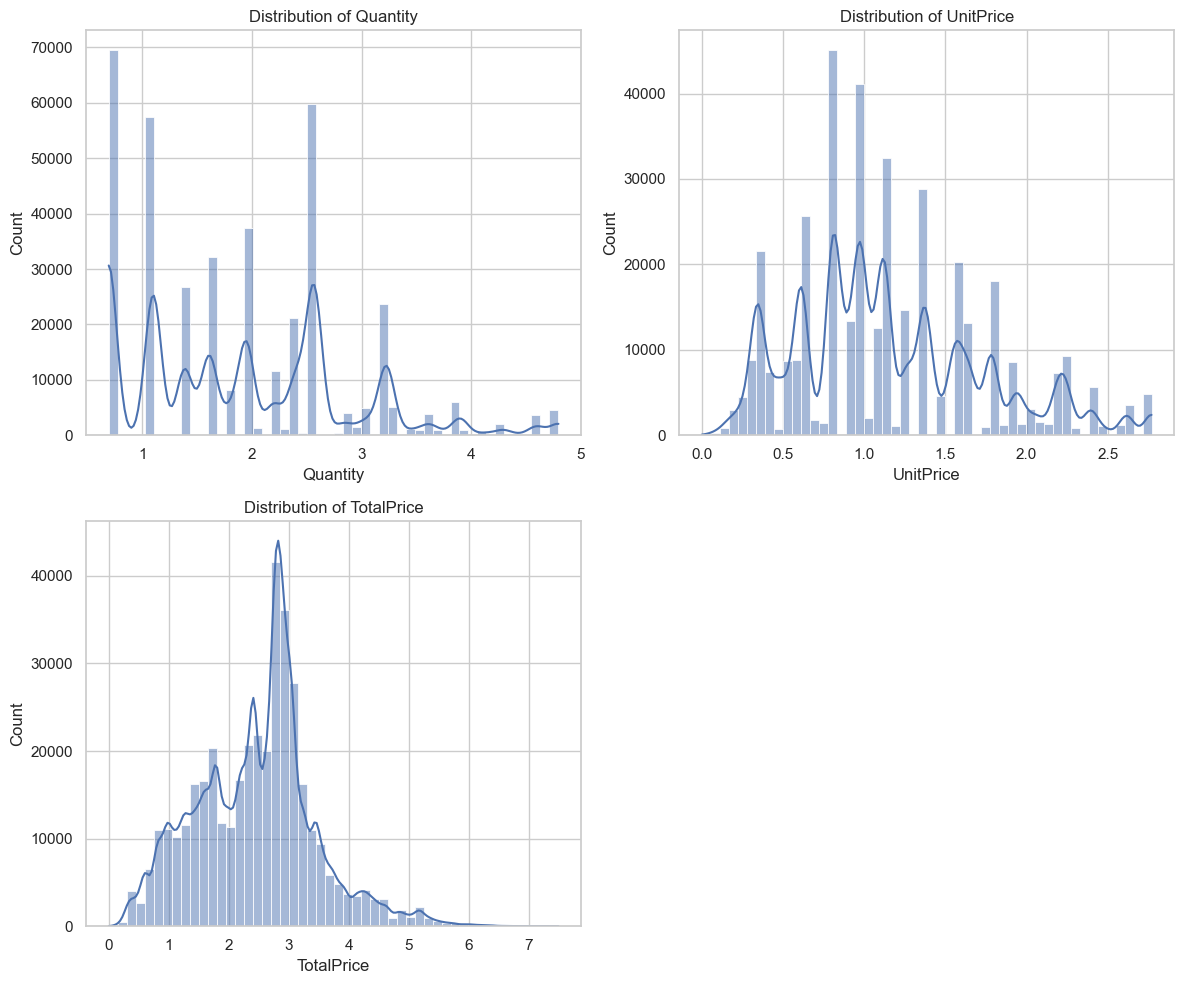

In [64]:
# iii) Visualize the distribution of log_transfomed numeric variables
log_transformed=np.log1p(df[['Quantity','UnitPrice','TotalPrice']])
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,10))
for i, col in enumerate (log_transformed.columns,1):
    plt.subplot(2,2,i)
    sns.histplot(data=log_transformed, x=col, bins=50, kde=True,)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f'log_transfromed_hist.png')
plt.show()

In [10]:
# 3. Customer Purchasing Behavior Analysis
# i) Transactions per customer
transactions_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()
transactions_per_customer.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

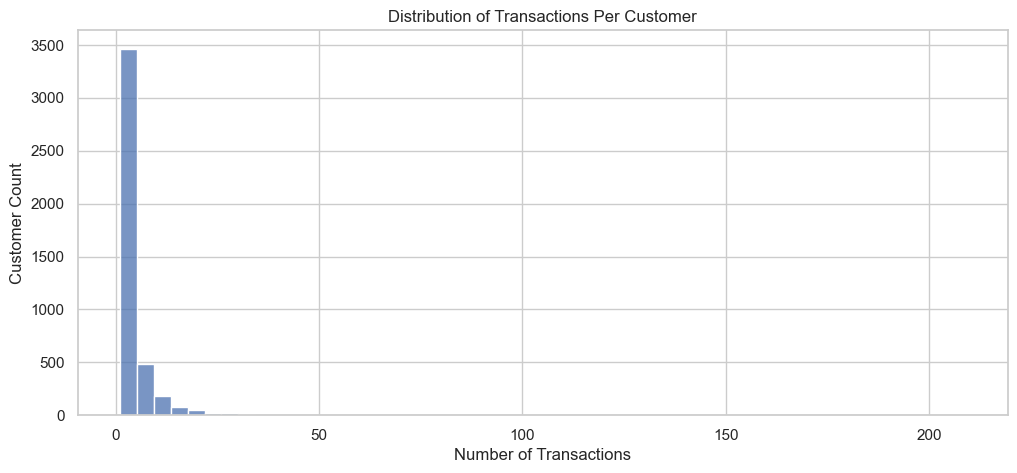

In [63]:
# ii) Visualize transactions per customer
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,5))
sns.histplot(transactions_per_customer, bins=50, kde=False)
plt.title(f'Distribution of Transactions Per Customer')
plt.xlabel('Number of Transactions')
plt.ylabel('Customer Count')
plt.savefig(f'transactions_per_customer_hist.png')
plt.show()

In [12]:
# iii) Revenue per customer
revenue_per_customer = df.groupby('CustomerID')['TotalPrice'].sum()
revenue_per_customer.describe()

count      4338.000000
mean       1761.581854
std        6319.990742
min           3.750000
25%         295.190000
50%         647.240000
75%        1581.452500
max      225194.650000
Name: TotalPrice, dtype: float64

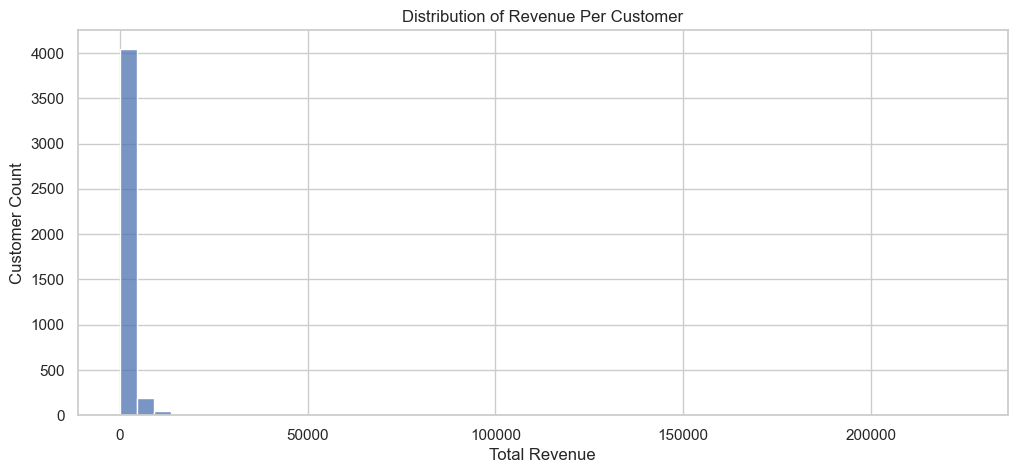

In [62]:
# iv) Visualize revenue per customer 
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,5))
sns.histplot(revenue_per_customer, bins=50, kde=False)
plt.title(f'Distribution of Revenue Per Customer')
plt.xlabel('Total Revenue')
plt.ylabel('Customer Count')
plt.savefig(f'revenue_per_customer_hist.png')
plt.show()

In [14]:
# v) Average order value (Customer Spending pattern)
average_order_value = revenue_per_customer/transactions_per_customer
average_order_value.describe()

count    4338.000000
mean      350.407890
std       341.576297
min         3.450000
25%       171.557000
50%       278.870500
75%       413.653750
max      6197.620000
dtype: float64

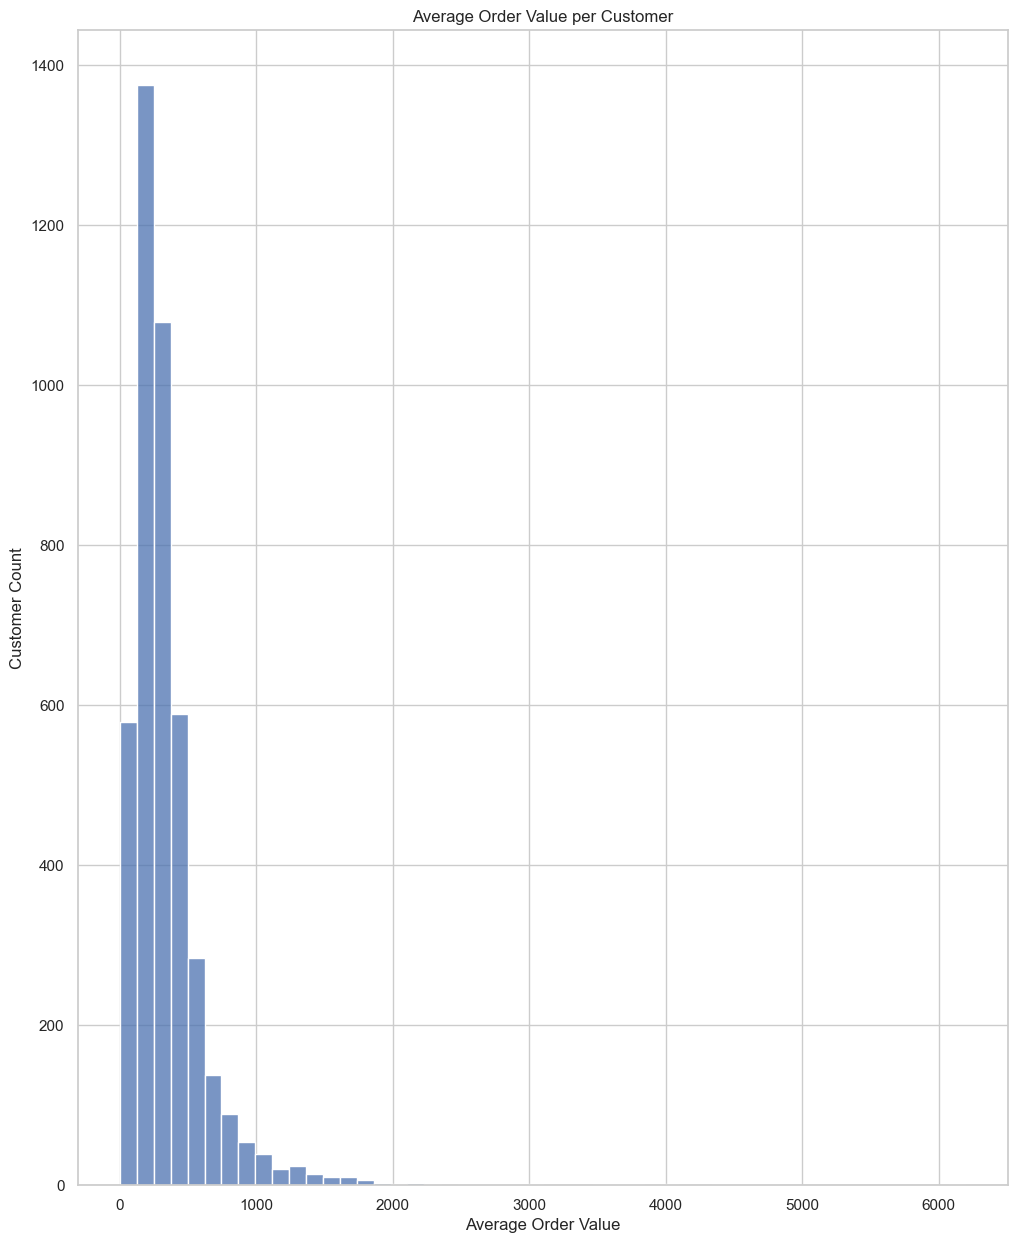

In [15]:
# vi) Visualize Average order value 
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,15))
sns.histplot(average_order_value, bins=50, kde=False)
plt.title(f'Average Order Value per Customer')
plt.xlabel('Average Order Value')
plt.ylabel('Customer Count')
plt.savefig(f'avg_order_value_per_customer_hist.png')
plt.show()

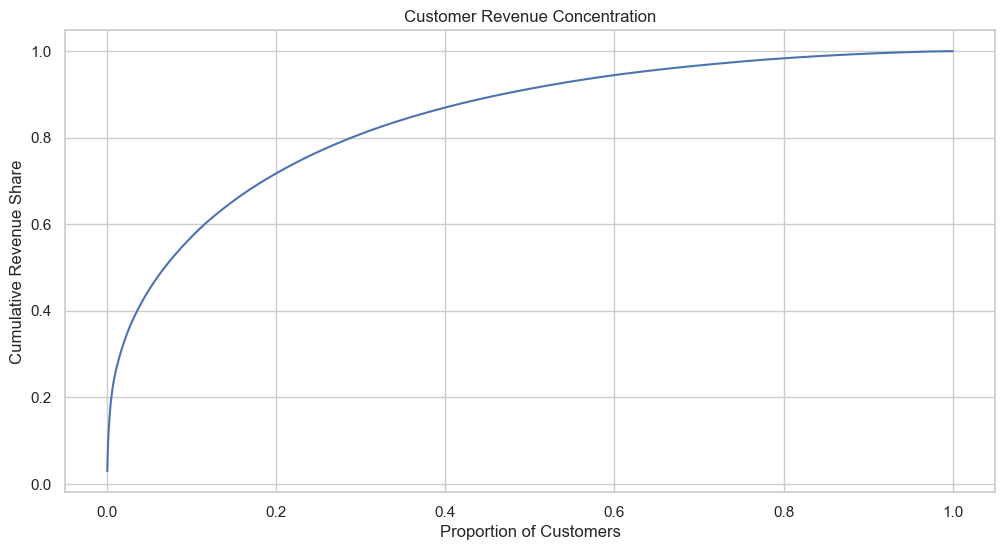

In [17]:
# vii) Customer revenue concentration
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False)
# Convert to dataframe
customer_revenue = customer_revenue.reset_index()
# Compute Cumulative Revenue Share
customer_revenue['cum_revenue'] = customer_revenue['TotalPrice'].cumsum()
# Compute cumulative revenue percentage
customer_revenue['cum_revenue_pct'] = customer_revenue['cum_revenue']/customer_revenue['TotalPrice'].sum()
# Compute Customer Percentage
customer_revenue['customer_pct'] = (customer_revenue.index + 1)/len(customer_revenue)
# Visualize customer concentration
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
sns.lineplot(x=customer_revenue['customer_pct'],y=customer_revenue['cum_revenue_pct'])
plt.title(f'Customer Revenue Concentration')
plt.ylabel('Cumulative Revenue Share')
plt.xlabel('Proportion of Customers')
plt.savefig(f'customer_revenue_concentration.png')
plt.show()

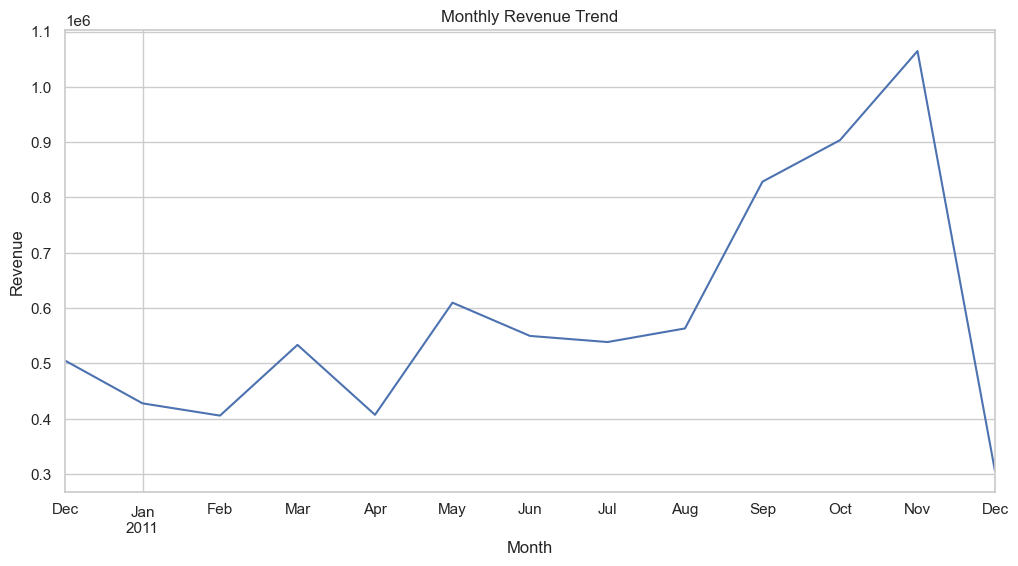

In [22]:
# 4. Temporal Analysis - Transactions Trends over time
# i) Extract Time Features
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# ii) monthly revenue trend
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

# iii) Visualize revenue trend
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
monthly_revenue.plot()
plt.title(f'Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.savefig(f'monthly_revenue_trend.png')
plt.show()

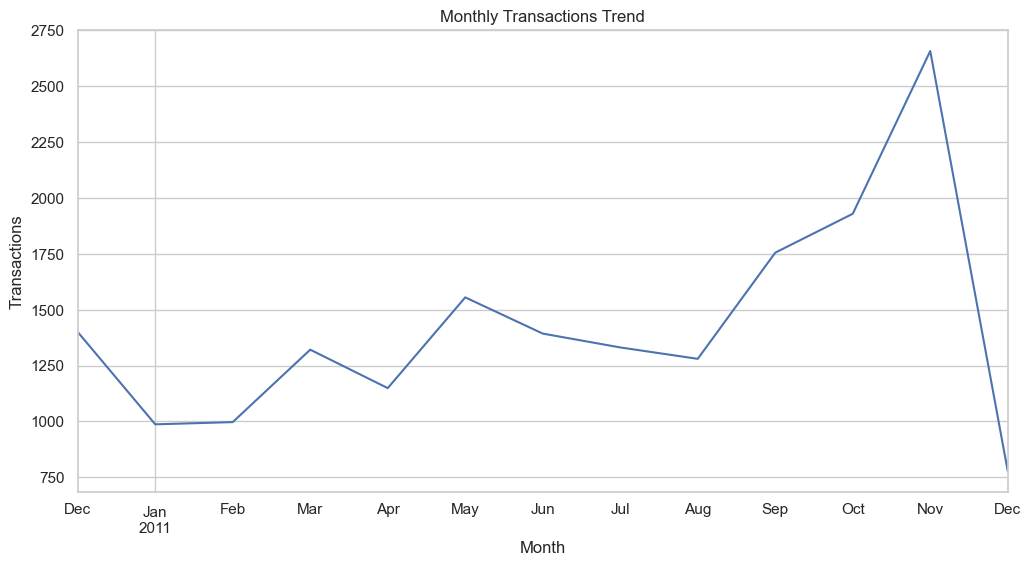

In [40]:
# iv) monthly transactions trend
monthly_transactions = df.groupby('YearMonth')['InvoiceNo'].nunique()

# v) visualize monthly transactions trend
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
monthly_transactions.plot()
plt.title(f'Monthly Transactions Trend')
plt.xlabel('Month')
plt.ylabel('Transactions')
plt.savefig(f'monthly_transactions_trend.png')
plt.show()

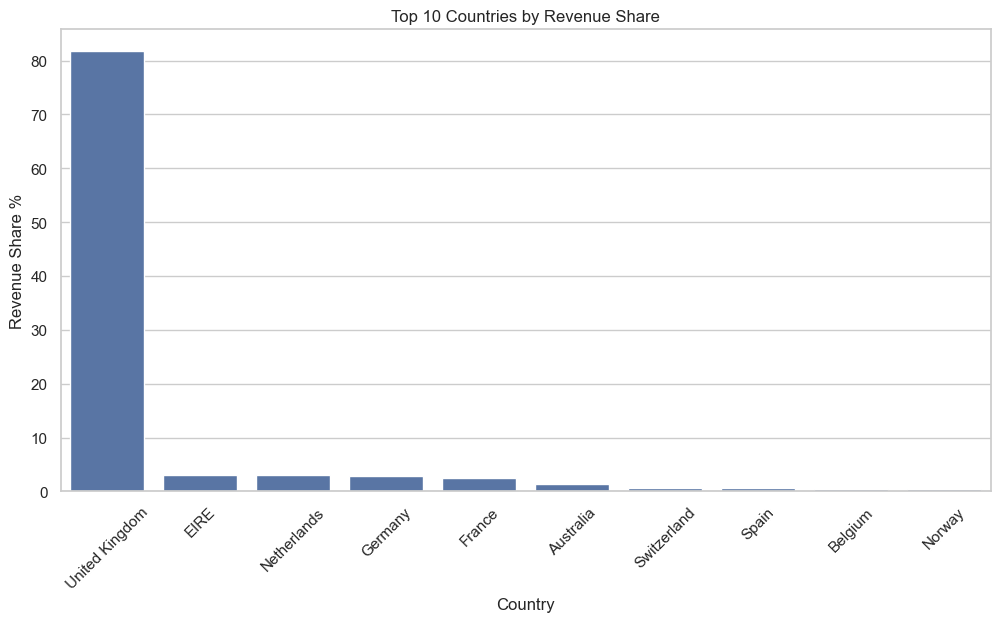

In [66]:
# 5. Geographic Analysis
# i) Revenue by country
revenue_by_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False).reset_index()
# ii) revenue share by country
revenue_by_country['revenue_pct'] = (revenue_by_country['TotalPrice']/revenue_by_country['TotalPrice'].sum())*100
# iii) visualize revenue by country
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
sns.barplot(data = revenue_by_country.head(10),x='Country', y='revenue_pct')
plt.title(f'Top 10 Countries by Revenue Share')
plt.xlabel('Country')
plt.ylabel('Revenue Share %')
plt.xticks(rotation=45)
plt.savefig(f'revenue_by_country.png')
plt.show()

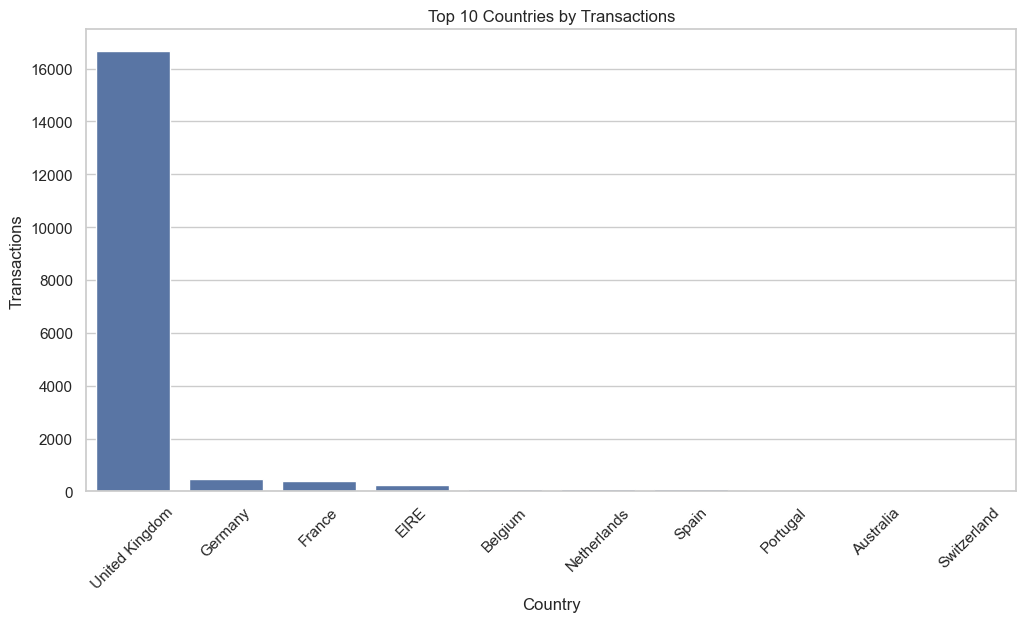

In [59]:
# iv) Transactions per country
transactions_per_country = df.groupby('Country')['InvoiceNo'].nunique().reset_index().rename(columns={'InvoiceNo':'transactions'}).sort_values(by='transactions', ascending=False)
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
sns.barplot(data=transactions_per_country.head(10),x='Country',y='transactions')
plt.title(f'Top 10 Countries by Transactions')
plt.xlabel('Country')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.savefig(f'transactions_per_country.png')
plt.show()

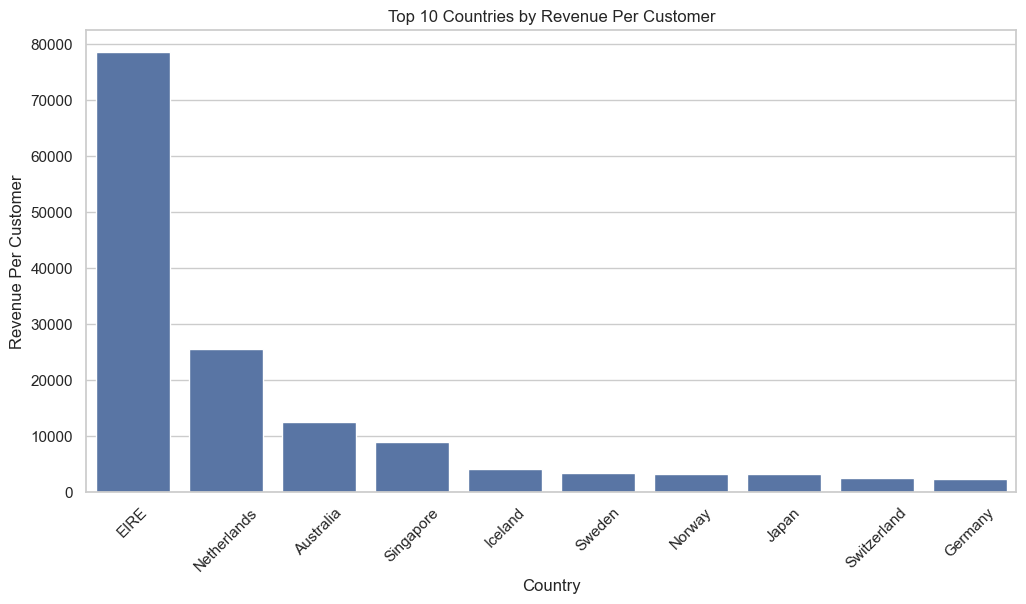

In [56]:
# v) customer revenue by country
country_metrics = df.groupby('Country').agg(total_revenue = ('TotalPrice','sum'), customers = ('CustomerID','nunique'))
country_metrics['revenue_per_customer'] = country_metrics['total_revenue']/country_metrics['customers']
country_metrics = country_metrics.sort_values(by = 'revenue_per_customer', ascending = False).reset_index()

# vi) visualize customer revenue by country
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,6))
sns.barplot(data = country_metrics.head(10),x='Country', y='revenue_per_customer')
plt.title(f'Top 10 Countries by Revenue Per Customer')
plt.xlabel('Country')
plt.ylabel('Revenue Per Customer')
plt.xticks(rotation=45)
plt.savefig(f'revenue_per_customer.png')
plt.show()